Import des Bibliothèques 

In [147]:
!pip install pytz
!pip install matplotlib
!pip install xlrd
!pip install chardet



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


   ---------------------------------------- 0.0/531.0 kB ? eta -:--:--
   ---------------------------------------- 0.0/531.0 kB ? eta -:--:--
   ---------------------------------------- 531.0/531.0 kB 11.4 MB/s  0:00:00



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
#Bibliothèques 
import pandas as pd 
import numpy as np 
from io import StringIO
from zoneinfo import ZoneInfo
import os
import matplotlib.pyplot as plt
import chardet

print ("librairies importées")


librairies importées


Code Ana 

Nettoyage des données day ahead prices pour 2024 2025

[Day-ahead Prices_2024-2025.csv] ✅ Aucune valeur manquante.
Dimensions : (8784, 3)
count    8784.000000
mean       58.019464
std        40.658254
min       -87.290000
25%        25.507500
50%        58.810000
75%        86.537500
max       284.210000
Name: Day-ahead Price (EUR/MWh), dtype: float64


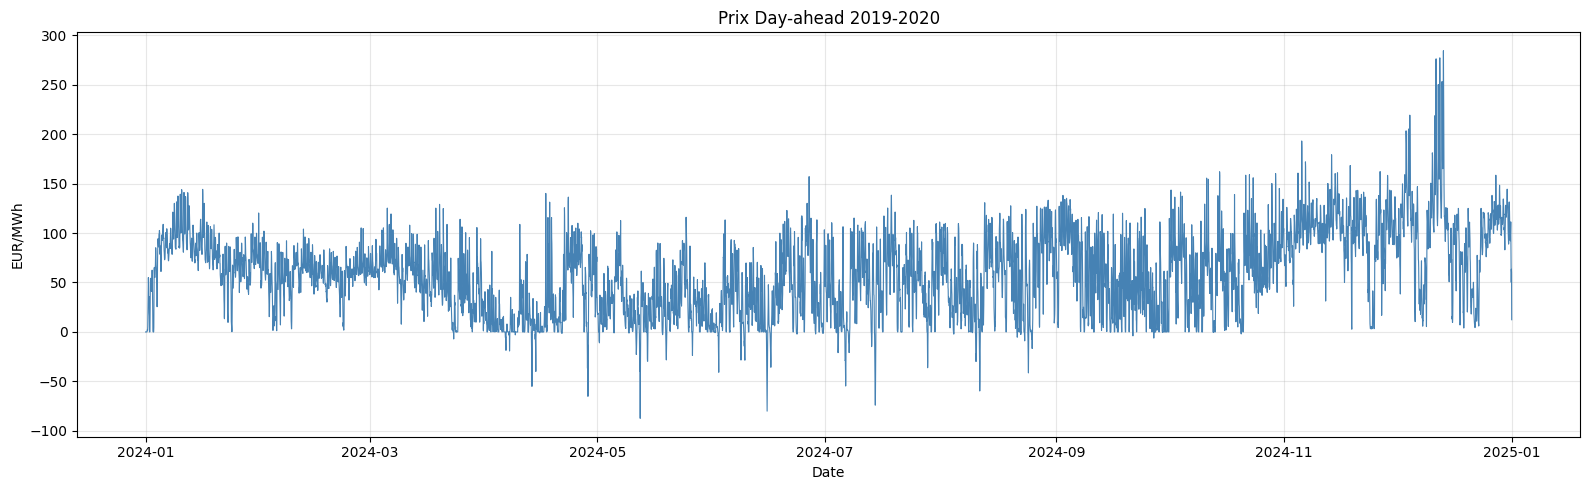

In [3]:
def harmonize_data_DayAhead_price(chemin_fichier):
    try:
        with open(chemin_fichier, 'r', encoding='utf-8') as f:
            raw_lines = f.readlines()

        cleaned_lines = []
        for line in raw_lines:
            line = line.strip()
            if line.startswith('"') and line.endswith('"'):
                line = line[1:-1]
            line = line.replace('""', '"')
            cleaned_lines.append(line)

        df = pd.read_csv(StringIO("\n".join(cleaned_lines)), sep=',', quotechar='"')
        df.columns = df.columns.str.strip()

    except Exception as e:
        print("Erreur lors de la lecture :", e)
        return None

    try:
        df = df[["MTU (UTC)", "Day-ahead Price (EUR/MWh)"]].copy()
        df[["Date_start", "Date_end"]] = df["MTU (UTC)"].str.split(" - ", expand=True)
        df = df.drop(columns=["MTU (UTC)"])
        df["Date_start"] = pd.to_datetime(df["Date_start"], format="%d/%m/%Y %H:%M:%S", errors='coerce')
        df["Date_end"]   = pd.to_datetime(df["Date_end"],   format="%d/%m/%Y %H:%M:%S", errors='coerce')
        df["Date_start"] = df["Date_start"].dt.tz_localize("UTC")
        df["Date_end"]   = df["Date_end"].dt.tz_localize("UTC")
        df["Day-ahead Price (EUR/MWh)"] = pd.to_numeric(df["Day-ahead Price (EUR/MWh)"], errors='coerce')
        df = df[["Date_start", "Date_end", "Day-ahead Price (EUR/MWh)"]]
    except Exception as e:
        print("Erreur lors du traitement :", e)
        return None
    
    # df = df.drop_duplicates(subset='Date_start', keep='first')

    nb_manquants = df.isnull().sum()
    nom_fichier = os.path.basename(chemin_fichier)
    if nb_manquants.any():
        print(f"[{nom_fichier}] ⚠️  Valeurs manquantes :")
        print(nb_manquants[nb_manquants > 0])
        print(df[df.isnull().any(axis=1)])
    else:
        print(f"[{nom_fichier}] ✅ Aucune valeur manquante.")

    return df


# Tests
path = "./Data/Day-ahead Prices_2024-2025.csv"
df_clean = harmonize_data_DayAhead_price(path)
print(f"Dimensions : {df_clean.shape}")
print(df_clean["Day-ahead Price (EUR/MWh)"].describe())

plt.figure(figsize=(16, 5))
plt.plot(df_clean["Date_start"], df_clean["Day-ahead Price (EUR/MWh)"], linewidth=0.8, color="steelblue")
plt.title("Prix Day-ahead 2019-2020")
plt.ylabel("EUR/MWh")
plt.xlabel("Date")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


Nettoyage des données day ahead prices avec date en UTC

[Day-ahead Prices_2019-2020.csv] ✅ Aucune valeur manquante.
Doublons : 0
Dimensions : (8760, 3)
count    8760.000000
mean       39.449507
std        14.022041
min       -24.920000
25%        31.000000
50%        38.650000
75%        47.430000
max       121.460000
Name: Day-ahead Price (EUR/MWh), dtype: float64
Date min : 2019-01-01 00:00:00+00:00
Date max : 2019-12-31 23:00:00+00:00


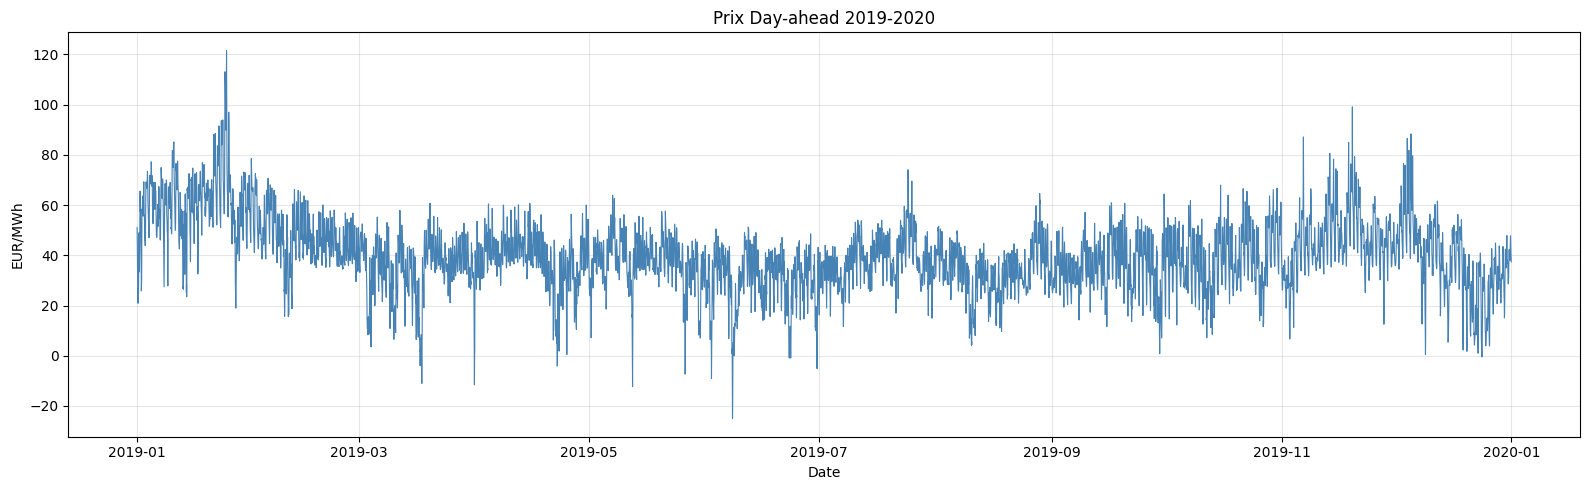

In [4]:
def clean_previous_data_prices(chemin_fichier):
    try:
        df = pd.read_csv(chemin_fichier)
        df = df.rename(columns={"Day-ahead Price [EUR/MWh]": "Day-ahead Price (EUR/MWh)"})
        df = df.drop(columns=[c for c in ["BZN|FR", "Currency", "MTU (CET/CEST)"] if c in df.columns])

        # Conversion du prix en float et suppression des NaN
        df["Day-ahead Price (EUR/MWh)"] = pd.to_numeric(df["Day-ahead Price (EUR/MWh)"], errors='coerce')
        df = df.dropna(subset=["Day-ahead Price (EUR/MWh)"]).reset_index(drop=True)

        # Détecter l'année de début depuis le nom du fichier
        annee_debut = os.path.basename(chemin_fichier).split("_")[-1][:4]

        # Générer les dates UTC
        df["Date_start"] = pd.date_range(start=f"{annee_debut}-01-01 00:00:00", periods=len(df), freq="h", tz="UTC")
        df["Date_end"]   = pd.date_range(start=f"{annee_debut}-01-01 01:00:00", periods=len(df), freq="h", tz="UTC")

        df = df[["Date_start", "Date_end", "Day-ahead Price (EUR/MWh)"]]

    except Exception as e:
        print("Erreur :", e)
        return None

    nom_fichier = os.path.basename(chemin_fichier)
    nb_manquants = df.isnull().sum()
    if nb_manquants.any():
        print(f"[{nom_fichier}] ⚠️  Valeurs manquantes :")
        print(nb_manquants[nb_manquants > 0])
    else:
        print(f"[{nom_fichier}] ✅ Aucune valeur manquante.")

    nb_doublons = df.duplicated(subset='Date_start').sum()
    print(f"Doublons : {nb_doublons}")
    print(f"Dimensions : {df.shape}")

    return df

path2 = "./Data/Day-ahead Prices_2019-2020.csv"
df_clean2 = clean_previous_data_prices(path2)
print(df_clean2["Day-ahead Price (EUR/MWh)"].describe())
print(f"Date min : {df_clean2['Date_start'].min()}")
print(f"Date max : {df_clean2['Date_start'].max()}")



plt.figure(figsize=(16, 5))
plt.plot(df_clean2["Date_start"], df_clean2["Day-ahead Price (EUR/MWh)"], linewidth=0.8, color="steelblue")
plt.title("Prix Day-ahead 2019-2020")
plt.ylabel("EUR/MWh")
plt.xlabel("Date")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [3]:

# Marie : Prix de l'énergie sur le marché SPOT
def clean_data_price (chemin_fichier):
    df = pd.read_csv(chemin_fichier)
    if df["BZN|FR"].isna().all(): # on vérifie que la colonne est vide avant de la supprimer
        df = df.drop(columns=["BZN|FR"])
        print('La colonne "BZN|FR" était vide et a été supprimée.')
    else:
        print('La colonne "BZN|FR" contient des données.')
    df=df.drop(columns=["Currency"])
    df[["Date_start", "Date_end"]] = df["MTU (CET/CEST)"].str.split(" - ", expand=True) 
    df = df.drop(columns=["MTU (CET/CEST)"]) # on supprime l'ancienne colonne de la plage horaire
    df["Date_start"] = pd.to_datetime(df["Date_start"], format="%d.%m.%Y %H:%M", utc = True).dt.tz_localize(None) # on change de le format de la date de début et de fin
    df["Date_end"] = pd.to_datetime(df["Date_end"], format="%d.%m.%Y %H:%M", utc = True).dt.tz_localize(None) # on change de le format de la date de fin
    print(df.shape)
    print(df.head())
    return df
#clean_data_price(".\Data\Day-ahead Prices_2019-2020.csv")



Nettoyage des données de température

In [ ]:
# Marine : Température & pseudo rayonnement
def clean_data_temperature (chemin_fichier): 
    fichier = pd.read_csv(chemin_fichier, sep=";")
    fichier["Horodate"] = pd.to_datetime(fichier["Horodate"], utc = True)
    fichier = fichier.drop(columns=["Année-Mois-Jour"])
    fichier = fichier.drop(columns = ["Année"])
    fichier = fichier.drop(columns = ["Mois"])
    fichier = fichier.drop(columns = ["Jour"])
    print(fichier.isna().sum())
    print(fichier.isnull().sum() )
    print(fichier.duplicated().sum())
    print(fichier.info())
    print(fichier.head())
    print(fichier.describe()) 
    return fichier

  

Nettoyage des données de Prévision J-1

In [32]:
def clean_eco2mix(chemin_fichier):
    try:
        # 1. Lecture du fichier (format TSV déguisé en XLS)
        df = pd.read_csv(
            chemin_fichier,
            sep='\t',
            encoding='latin-1',
            engine='python',
            skipinitialspace=True
        )

        # 2. Correction du décalage de colonnes (propre à Eco2mix)
        # On décale les noms vers la droite et on supprime la première colonne fantôme
        new_columns = df.columns.tolist()
        new_columns = new_columns[1:] + ["col_en_trop"]
        df.columns = new_columns
        df = df.iloc[:, 1:].copy()
        
        # Supprimer les lignes vides ou de copyright en bas de fichier
        df = df.dropna(subset=["Date", "Heures"])

        print(f"[{os.path.basename(chemin_fichier)}] Colonnes importées : {df.columns.tolist()}")
    
    except Exception as e:
        print("Erreur lors de la lecture :", e)
        return None

    try:
        # 3. Préparation des colonnes de données
        # On identifie les colonnes à convertir en numérique (tout sauf Date et Heures)
        cols_data = [c for c in df.columns if c not in ["Date", "Heures", "col_en_trop"]]
        
        # Conversion massive : les "ND" et erreurs deviennent NaN
        for col in cols_data:
            df[col] = pd.to_numeric(df[col], errors='coerce')

        # 4. Agrégation horaire (somme des 4 quarts d'heure)
        # On crée un index de groupe (0,0,0,0, 1,1,1,1, ...)
        df = df.reset_index(drop=True)
        df["groupe"] = df.index // 4

        # On somme toutes les colonnes numériques
        df_agg = df.groupby("groupe")[cols_data].mean().reset_index(drop=True)

        # 5. Reconstruction de l'axe temporel
        annee = os.path.basename(chemin_fichier).split("_")[-1][:4]
        dates = pd.date_range(
            start=f"{annee}-01-01 00:00:00", 
            periods=len(df_agg), 
            freq="h", 
            tz="UTC"
        )

        # 6. Assemblage du DataFrame final
        df_final = pd.concat([
            pd.DataFrame({
                "Date_start": dates,
                "Date_end": dates + pd.Timedelta("1h")
            }),
            df_agg
        ], axis=1)

    except Exception as e:
        print("Erreur lors du traitement :", e)
        return None

    # --- Diagnostics ---
    nom_fichier = os.path.basename(chemin_fichier)
    
    # 1. Analyse des valeurs manquantes par colonne
    colonnes_vides = df_final.isnull().sum()
    nb_manquants_total = colonnes_vides.sum()

    if nb_manquants_total > 0:
        print(f"[{nom_fichier}] ⚠️ {nb_manquants_total} valeurs manquantes détectées au total.")
        # Ligne ajoutée : on affiche le détail uniquement pour les colonnes concernées
        print("Détail des colonnes impactées :\n", colonnes_vides[colonnes_vides > 0])
    else:
        print(f"[{nom_fichier}] ✅ Aucune valeur manquante.")

    # 2. Analyse de la continuité temporelle
    diff = df_final["Date_start"].diff().dropna()
    trous = diff[diff != pd.Timedelta("1h")]
    if len(trous) == 0:
        print(f"[{nom_fichier}] ✅ Série temporelle continue.")
    else:
        print(f"[{nom_fichier}] ⚠️ {len(trous)} trou(s) dans la chronologie.")

    print(f"Dimensions finales : {df_final.shape}")

    return df_final

# ======================
# TEST
# ======================
path_eco2mix = "./Data/eCO2mix prod/eCO2mix_RTE_Annuel-Definitif_2019.xls"
df_eco2mix = clean_eco2mix(path_eco2mix)
print(df_eco2mix.head())

[eCO2mix_RTE_Annuel-Definitif_2019.xls] Colonnes importées : ['Date', 'Heures', 'Consommation', 'Prévision J-1', 'Prévision J', 'Fioul', 'Charbon', 'Gaz', 'Nucléaire', 'Eolien', 'Solaire', 'Hydraulique', 'Pompage', 'Bioénergies', 'Ech. physiques', 'Taux de Co2', 'Ech. comm. Angleterre', 'Ech. comm. Espagne', 'Ech. comm. Italie', 'Ech. comm. Suisse', 'Ech. comm. Allemagne-Belgique', 'Fioul - TAC', 'Fioul - Cogén.', 'Fioul - Autres', 'Gaz - TAC', 'Gaz - Cogén.', 'Gaz - CCG', 'Gaz - Autres', 'Hydraulique - Fil de l?eau + éclusée', 'Hydraulique - Lacs', 'Hydraulique - STEP turbinage', 'Bioénergies - Déchets', 'Bioénergies - Biomasse', 'Bioénergies - Biogaz', 'Stockage batterie', 'Déstockage batterie', 'Eolien terrestre', 'Eolien offshore', 'col_en_trop']
[eCO2mix_RTE_Annuel-Definitif_2019.xls] ⚠️ 35040 valeurs manquantes détectées au total.
Détail des colonnes impactées :
 Stockage batterie      8760
Déstockage batterie    8760
Eolien terrestre       8760
Eolien offshore        8760
dtype:

Création d'un dataframe avec l'ensemble des data "day ahead prices" depuis 2019 


Période : 2019-2020
[Day-ahead Prices_2019-2020.csv] ✅ Aucune valeur manquante.
Doublons : 0
Dimensions : (8760, 3)
  Lignes     : 8760
  Date min   : 2019-01-01 00:00:00+00:00
  Date max   : 2019-12-31 23:00:00+00:00

Période : 2020-2021
[Day-ahead Prices_2020-2021.csv] ✅ Aucune valeur manquante.
Doublons : 0
Dimensions : (8784, 3)
  Lignes     : 8784
  Date min   : 2020-01-01 00:00:00+00:00
  Date max   : 2020-12-31 23:00:00+00:00

Période : 2021-2022
[Day-ahead Prices_2021-2022.csv] ✅ Aucune valeur manquante.
Doublons : 0
Dimensions : (8760, 3)
  Lignes     : 8760
  Date min   : 2021-01-01 00:00:00+00:00
  Date max   : 2021-12-31 23:00:00+00:00

Période : 2022-2023
[Day-ahead Prices_2022-2023.csv] ✅ Aucune valeur manquante.
Doublons : 0
Dimensions : (8760, 3)
  Lignes     : 8760
  Date min   : 2022-01-01 00:00:00+00:00
  Date max   : 2022-12-31 23:00:00+00:00

Période : 2023-2024
[Day-ahead Prices_2023-2024.csv] ✅ Aucune valeur manquante.
Doublons : 0
Dimensions : (8760, 3)
  Ligne

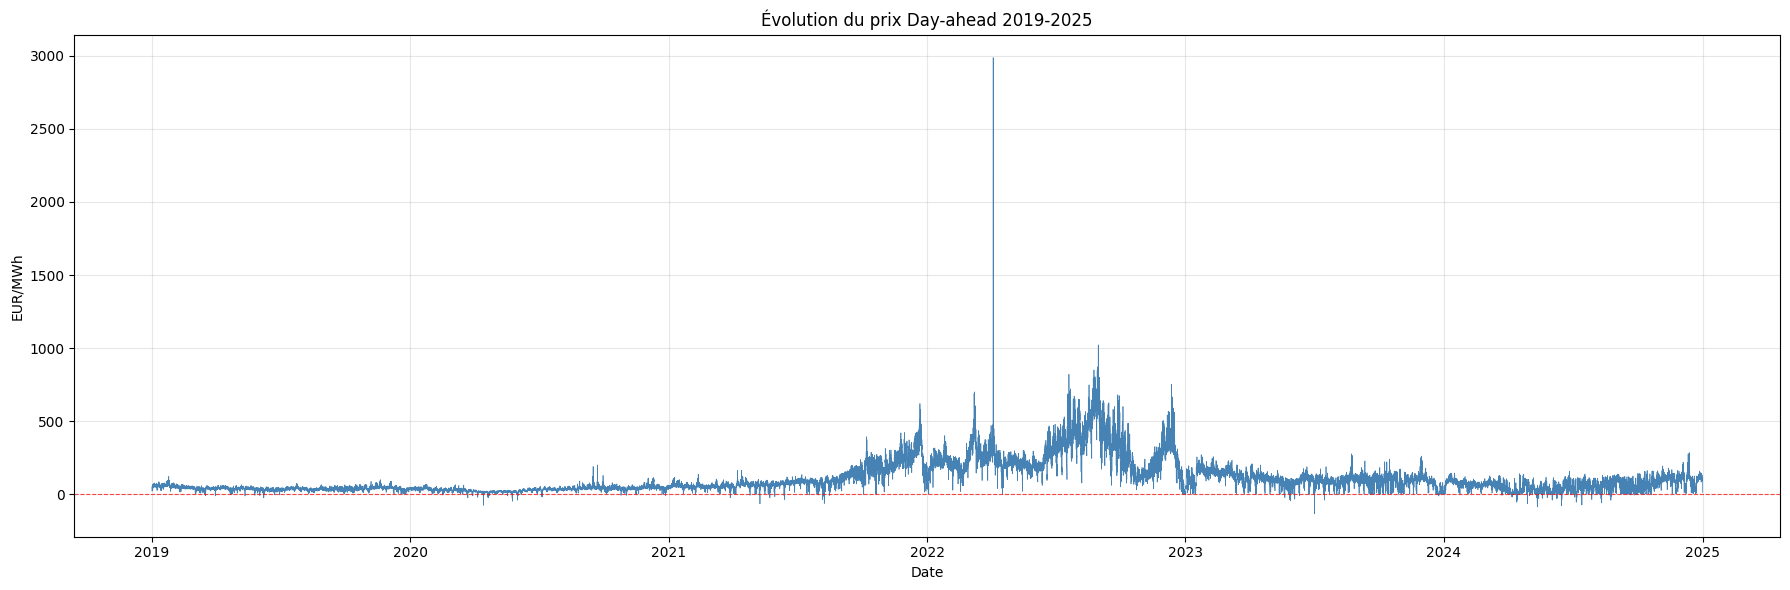

In [6]:
paths = {
    "2019-2020": "./Data/Day-ahead Prices_2019-2020.csv",
    "2020-2021": "./Data/Day-ahead Prices_2020-2021.csv",
    "2021-2022": "./Data/Day-ahead Prices_2021-2022.csv",
    "2022-2023": "./Data/Day-ahead Prices_2022-2023.csv",
    "2023-2024": "./Data/Day-ahead Prices_2023-2024.csv",
    "2024-2025": "./Data/Day-ahead Prices_2024-2025.csv",
}

dfs = {}

for periode, chemin in paths.items():
    print(f"\n{'='*40}")
    print(f"Période : {periode}")

    if periode == "2024-2025":
        df = harmonize_data_DayAhead_price(chemin)
    else:
        df = clean_previous_data_prices(chemin)

    if df is None:
        print(f"  ⚠️  Échec du chargement pour {periode}")
        continue

    print(f"  Lignes     : {len(df)}")
    print(f"  Date min   : {df['Date_start'].min()}")
    print(f"  Date max   : {df['Date_start'].max()}")

    dfs[periode] = df

# Concaténation
print(f"\n{'='*40}")
print("Concaténation de tous les DataFrames...")

df_all = pd.concat(dfs.values())

print(f"Dimensions totales : {df_all.shape}")
print(f"Valeurs manquantes :\n{df_all.isnull().sum().to_string()}")
nb_doublons = df_all.duplicated(subset='Date_start').sum()
print(f"Doublons           : {nb_doublons}")
if nb_doublons > 0:
    print(df_all[df_all.duplicated(subset='Date_start', keep=False)].sort_values("Date_start"))
print(df_all.head())

print(df_all["Day-ahead Price (EUR/MWh)"].describe())

# Graphique evolution des prix
df_plot = df_all.sort_values("Date_start").dropna(subset=["Date_start", "Day-ahead Price (EUR/MWh)"])

plt.figure(figsize=(18, 6))
plt.plot(df_plot["Date_start"], df_plot["Day-ahead Price (EUR/MWh)"], linewidth=0.5, color="steelblue")
plt.title("Évolution du prix Day-ahead 2019-2025")
plt.ylabel("EUR/MWh")
plt.xlabel("Date")
plt.grid(True, alpha=0.3)

# Ligne horizontale à 0 pour repérer les prix négatifs
plt.axhline(y=0, color='red', linewidth=0.8, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

Création d'un d'un data frame contenant les données de Prévision J-1

[eCO2mix_RTE_Annuel-Definitif_2019.xls] ⚠️ 35040 valeurs manquantes détectées.
[eCO2mix_RTE_Annuel-Definitif_2019.xls] ✅ Série temporelle continue.
Dimensions finales : (8760, 38)
[eCO2mix_RTE_Annuel-Definitif_2020.xls] ⚠️ 35136 valeurs manquantes détectées.
[eCO2mix_RTE_Annuel-Definitif_2020.xls] ✅ Série temporelle continue.
Dimensions finales : (8784, 38)
[eCO2mix_RTE_Annuel-Definitif_2021.xls] ✅ Aucune valeur manquante.
[eCO2mix_RTE_Annuel-Definitif_2021.xls] ✅ Série temporelle continue.
Dimensions finales : (8760, 38)
[eCO2mix_RTE_Annuel-Definitif_2022.xls] ✅ Aucune valeur manquante.
[eCO2mix_RTE_Annuel-Definitif_2022.xls] ✅ Série temporelle continue.
Dimensions finales : (8760, 38)
[eCO2mix_RTE_Annuel-Definitif_2023.xls] ✅ Aucune valeur manquante.
[eCO2mix_RTE_Annuel-Definitif_2023.xls] ✅ Série temporelle continue.
Dimensions finales : (8760, 38)
[eCO2mix_RTE_Annuel-Definitif_2024.xls] ✅ Aucune valeur manquante.
[eCO2mix_RTE_Annuel-Definitif_2024.xls] ✅ Série temporelle continue.


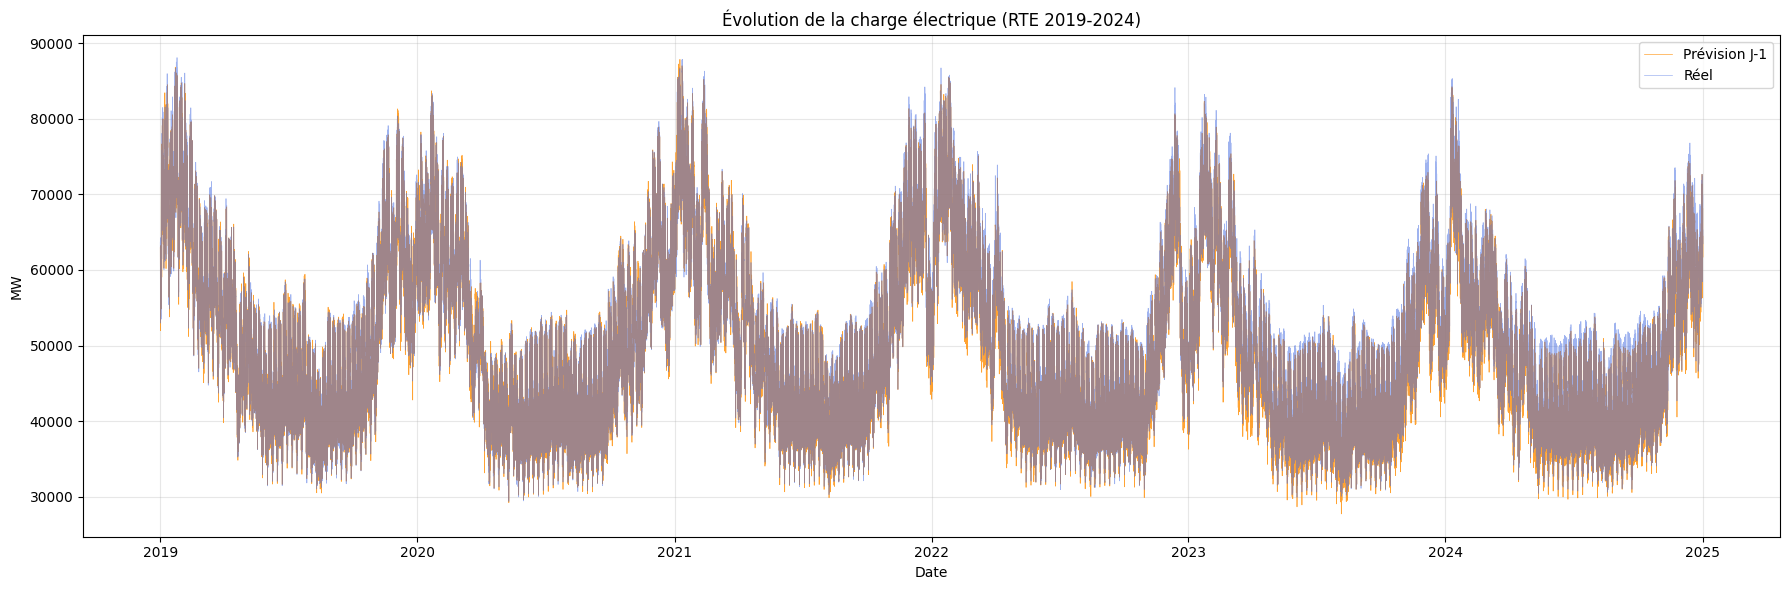

In [28]:
# ======================
# TRAITEMENT GLOBAL
# ======================

paths_eco2mix = {
    "2019": "./Data/eCO2mix prod/eCO2mix_RTE_Annuel-Definitif_2019.xls",
    "2020": "./Data/eCO2mix prod/eCO2mix_RTE_Annuel-Definitif_2020.xls",
    "2021": "./Data/eCO2mix prod/eCO2mix_RTE_Annuel-Definitif_2021.xls",
    "2022": "./Data/eCO2mix prod/eCO2mix_RTE_Annuel-Definitif_2022.xls",
    "2023": "./Data/eCO2mix prod/eCO2mix_RTE_Annuel-Definitif_2023.xls",
    "2024": "./Data/eCO2mix prod/eCO2mix_RTE_Annuel-Definitif_2024.xls",
}

dfs_eco2mix = []
for annee, chemin in paths_eco2mix.items():
    if os.path.exists(chemin):
        df = clean_eco2mix(chemin)
        if df is not None:
            dfs_eco2mix.append(df)
    else:
        print(f"Fichier manquant : {chemin}")

# Fusion finale
df_eco2mix_all = pd.concat(dfs_eco2mix).sort_values("Date_start").reset_index(drop=True)

print(f"\nDimensions finales eco2mix : {df_eco2mix_all.shape}")
print(df_eco2mix_all.head())

# ======================
# VISUALISATION
# ======================
plt.figure(figsize=(18, 6))
# On trace la prévision J-1
plt.plot(df_eco2mix_all["Date_start"], df_eco2mix_all["Prévision J-1"], 
         label="Prévision J-1", linewidth=0.5, color="darkorange", alpha=0.8)

# Optionnel : On peut tracer la consommation réelle pour comparer
if "Consommation" in df_eco2mix_all.columns:
    plt.plot(df_eco2mix_all["Date_start"], df_eco2mix_all["Consommation"], 
             label="Réel", linewidth=0.5, color="royalblue", alpha=0.5)

plt.title("Évolution de la charge électrique (RTE 2019-2024)")
plt.ylabel("MW")
plt.xlabel("Date")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Création d'un dataframe avec les données date, day ahead prices, Prévision J-1 + "Nucléaire", "Eolien", "Solaire", "Hydraulique", "Gaz"

In [40]:
# 1. Liste des colonnes de production à conserver
cols_prod = ["Nucléaire", "Eolien", "Solaire", "Hydraulique", "Gaz"]

# 2. Fusion des DataFrames en incluant les colonnes de production
df_merged = pd.merge(
    df_eco2mix_all[["Date_start", "Date_end", "Prévision J-1"] + cols_prod],
    df_all[["Date_start", "Day-ahead Price (EUR/MWh)"]],
    on="Date_start",
    how="inner"
)

# 3. Restructuration du DataFrame final
# On crée un dictionnaire de base
data_final = {
    "Date":               df_merged["Date_start"].dt.date,
    "Heure_début":        df_merged["Date_start"].dt.strftime("%H:%M"),
    "Heure_fin":          df_merged["Date_end"].dt.strftime("%H:%M"),
    "Day_ahead_price":    df_merged["Day-ahead Price (EUR/MWh)"],
    "Prévision_conso_J1": df_merged["Prévision J-1"],
}

# On ajoute dynamiquement les colonnes de production au dictionnaire
for col in cols_prod:
    data_final[col] = df_merged[col]

df_final = pd.DataFrame(data_final)

# 4. Sauvegarde en Pickle
df_final.to_pickle("./Data/df_final_DayAheadPrices_PrevJ1.pkl")

# --- Vérification ---
print(f"Dimensions : {df_final.shape}")
print("\n--- Valeurs manquantes ---")
print(df_final.isnull().sum())
print(f"\nDoublons : {df_final.duplicated().sum()}")

# Affichage des premières lignes pour vérifier la présence des nouvelles colonnes
print("\nAperçu des données :")
print(df_final.head(10))

Dimensions : (52608, 10)

--- Valeurs manquantes ---
Date                  0
Heure_début           0
Heure_fin             0
Day_ahead_price       0
Prévision_conso_J1    0
Nucléaire             0
Eolien                0
Solaire               0
Hydraulique           0
Gaz                   0
dtype: int64

Doublons : 0

Aperçu des données :
         Date Heure_début Heure_fin  Day_ahead_price  Prévision_conso_J1  \
0  2019-01-01       00:00     01:00            51.00             62987.5   
1  2019-01-01       01:00     02:00            46.27             60837.5   
2  2019-01-01       02:00     03:00            39.78             59500.0   
3  2019-01-01       03:00     04:00            27.87             56012.5   
4  2019-01-01       04:00     05:00            23.21             53300.0   
5  2019-01-01       05:00     06:00            22.64             52187.5   
6  2019-01-01       06:00     07:00            20.90             52162.5   
7  2019-01-01       07:00     08:00            26.

Vérification de la conso annuelle 

2019 : 472 TWh - 
2020 : 448.5 TWh - 
2021 : 471.5 TWh - 
2022 : 453.7 TWh - 
2023 : 438.4 TWh - 
2024 : 442.3 TWh 

[Conso brute RTE affichée sur les graphiques en ligne](https://analysesetdonnees.rte-france.com/consommation/synthese)

on obtient quelques variations car on a certainement pas traité les données de la même manière 

In [42]:
df_eco2mix_all['Annee'] = df_eco2mix_all['Date_start'].dt.year

bilan = df_eco2mix_all.groupby('Annee').agg({
    'Consommation': 'mean',
    'Prévision J-1': 'mean'
})

# Calcul final : Moyenne MW * 8760 heures / 1 000 000
bilan['Conso_TWh'] = (bilan['Consommation'] * 8760) / 1_000_000
bilan['Prev_TWh'] = (bilan['Prévision J-1'] * 8760) / 1_000_000

print(bilan[['Conso_TWh', 'Prev_TWh']])

        Conso_TWh    Prev_TWh
Annee                        
2019   470.477142  468.480030
2020   445.362499  444.353137
2021   468.592967  466.606275
2022   450.987335  445.121863
2023   435.572892  425.665580
2024   438.883883  428.844426


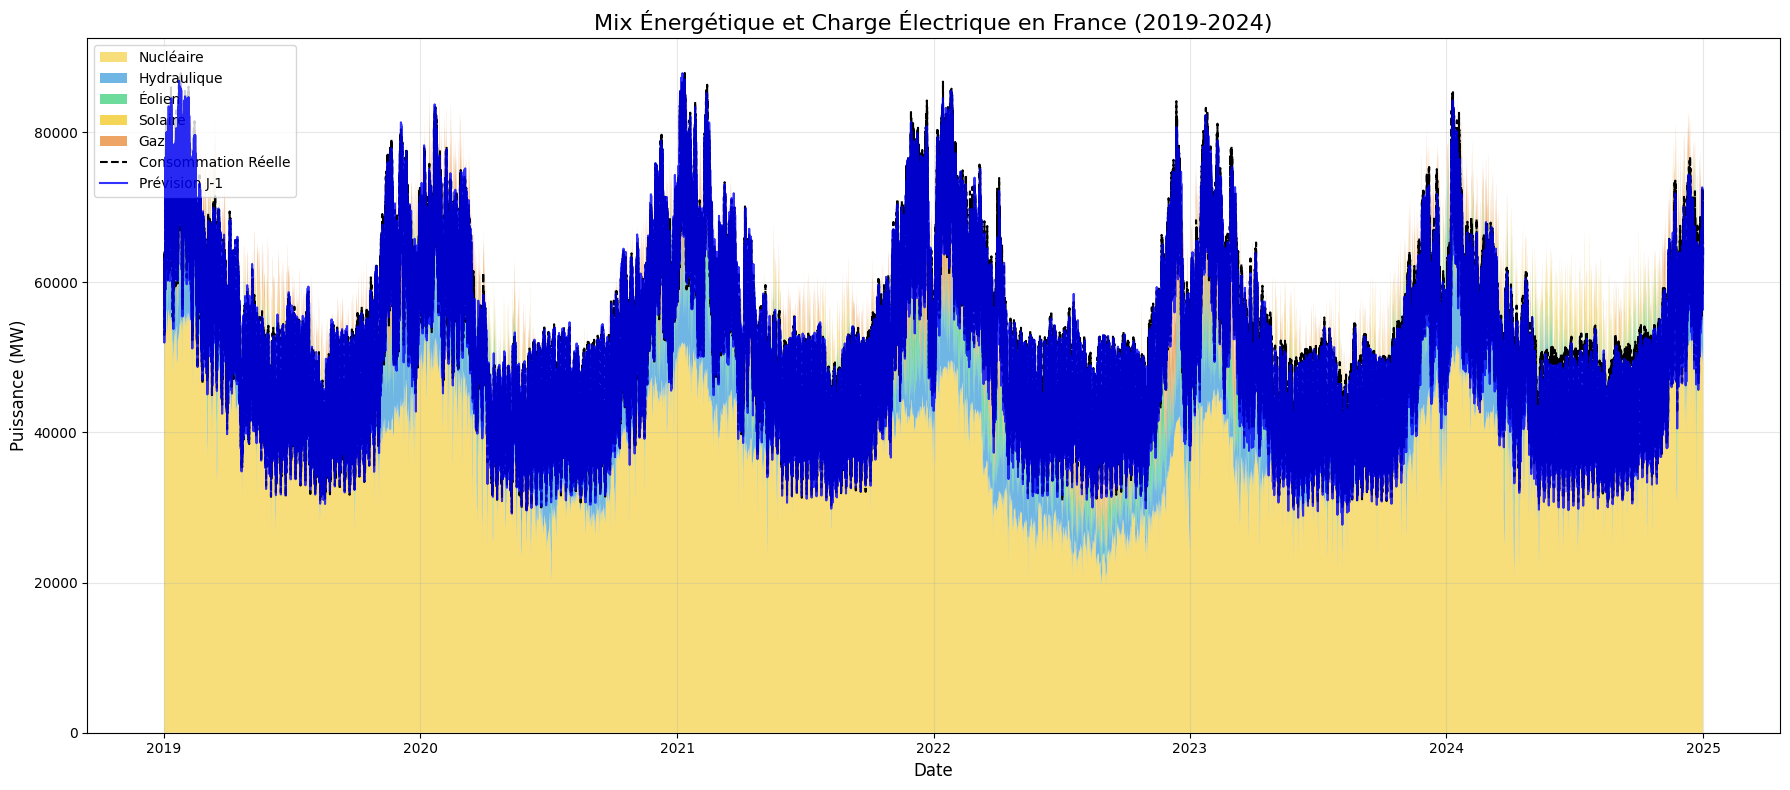

In [41]:
# 1. Préparation des données
df_plot = df_eco2mix_all.copy()

# Colonnes de production
cols_prod = ["Nucléaire", "Hydraulique", "Eolien", "Solaire", "Gaz"]

# CRUCIAL : On remplit les NaNs par 0 pour le stackplot, 
# sinon le graphique d'aires ne s'affiche pas correctement.
df_plot[cols_prod] = df_plot[cols_prod].fillna(0)

# CRUCIAL : Pour la consommation et la prévision, on utilise .ffill() (forward fill)
# pour boucher les trous sans mettre de 0 (ce qui ferait tomber la courbe au sol).
df_plot["Consommation"] = df_plot["Consommation"].ffill()
df_plot["Prévision J-1"] = df_plot["Prévision J-1"].ffill()

# 2. Création du graphique
plt.figure(figsize=(18, 8))

# On trace les aires empilées (La production)
plt.stackplot(df_plot["Date_start"], 
              df_plot["Nucléaire"], 
              df_plot["Hydraulique"], 
              df_plot["Eolien"], 
              df_plot["Solaire"], 
              df_plot["Gaz"],
              labels=["Nucléaire", "Hydraulique", "Éolien", "Solaire", "Gaz"],
              alpha=0.7,
              colors=["#f5d142", "#3498db", "#2ecc71", "#f1c40f", "#e67e22"],
              zorder=1) # Arrière-plan

# 3. On ajoute les lignes de Consommation et Prévision
# zorder=5 force ces lignes à être AU-DESSUS des aires colorées
plt.plot(df_plot["Date_start"], df_plot["Consommation"], 
         label="Consommation Réelle", color="black", linewidth=1.5, linestyle="--", zorder=5)

plt.plot(df_plot["Date_start"], df_plot["Prévision J-1"], 
         label="Prévision J-1", color="blue", linewidth=1.5, alpha=0.8, zorder=6)

# 4. Habillage
plt.title("Mix Énergétique et Charge Électrique en France (2019-2024)", fontsize=16)
plt.ylabel("Puissance (MW)", fontsize=12)
plt.xlabel("Date", fontsize=12)
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.show()